# Welcome to Machine Learning Housing Corporation!
Your task is to predict median house values in Californian districts, given a number of features from these districts.

In [ ]:
import pandas as pd
ca_housing = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/California_housing.csv"

housing = pd.read_csv(ca_housing)

## 1. Examine the data
Work with a partner and do the initial exploration:
* Did the data output properly? Look at the head and tail of the DataFrame.
* What are the columns in the DataFrame? What are their datatypes?
* How big is the DataFrame? Are there missing data?
* Summarize the numerical attributes to look at the dispersion of data points
* For categorical columns, what are the different values and are they repetitive?


In [ ]:
## Did the data output properly? Look at the head and tail of the DataFrame.


In [ ]:
## What are the columns in the DataFrame? What are their datatypes?
## How big is the DataFrame? Are there missing data?


### Summarizing numerical attributes.
There are different ways to do this. First we can use the `describe()` method to get descriptive statistics of the data that includes the  to explore the range/dispersion (mix and max), the central tendency, and other metrics.
  
Another way to get a feel of the type of data you are working with is to visualize the numerical attributes. You can get a quick feel of the data by plotting the `hist()` method on the whole dataset. `hist()` is part of the `import matplotlib.pyplot as plt` package.

In [ ]:
## Summarize the numerical attributes to look at the dispersion of data points


In [ ]:
### Visualize the histogram of the numerical attributes
%matplotlib inline
import matplotlib.pyplot as plt
housing.hist()


#### Notice a few things in these histograms:
1. The median income attribute does not look like it's expressed in US dollars (USD). It turns out this data has been scaled and capped at 15.0001 for higher median income, and at 0.4999 for lower median incomes. The number represent roughly tens of thousands of dollars (e.g. 3 actually means about \$30,000).
2. The housing median age and the median house value were also capped. These may become problematic because your ML algorithms may learn that prices never go beyond that limit. If you want to make predictions beyond \$500,000, then you have 2 main options:
    - a) Collect proper labels for the districts whose labels were capped.
    - b) Remove those districts from the training set (and also from the test set, since your system should not be evaluated poorly if it predicts values beyond \$500,000).
3. These attributes have very different scales. We will explore **feature scaling**.
4. Many histograms are *tail heavy*: they extend much farther to the right of the median than to the left. This make it a bit harder for some ML algorithms to detect patterns. We will try **transforming these attributes** to have more bell-shaped distributions.

### Working with categorical attributes
The majority of attributes are numerical, except the `ocean_proximity` field. There appears to be repetitive values in this column. To see how many different districts there are in each cateogry, we can use the `value_counts()` method.

In [ ]:
### How many different districts there are in each cateogry
housing['ocean_proximity']

## 2. Split data into Train and Test sets
Our brain is an amazing pattern detection system, which means that it is highly prone to overfitting. If we look at the test set, we might stumble upon some seemingly interesting pattern in the test data that leads us to select a particular kind of ML model. When we estimate the generalization error using the test set, our estimate will be too optimistic and we will launch a system that will not perform as well as expected. This is called __*data snooping*__ bias.

Let's pick some instances randomly, typically 20% of the dataset, and set them aside.

**Scikit-Learn** provides a few functions to split datasets into multiple subsets in various ways. `train_test_split` is the simpliest function.
- `test_size` parameter is to set the proportion of data for test set
- The `random_state` parameter allows you to set the random number generator seed.
  - You can pass it multiple datasets with an identical number of rows, and it will split them on the same indices (this is very useful if we have a separate DataFrame for labels):

In [ ]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split()

In [ ]:
# train_set
# test_set

### Correlation matrix
We can compute the *standard correlation coefficient* (also called *Pearson's r*) between every pair of attributes using the `corr()` method.

In [ ]:
### Drop the categorical attribute
housing.drop("ocean_proximity", axis=1)

In [ ]:
### Build the correlation matrix using .corr()
corr_matrix =

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


<Axes: >

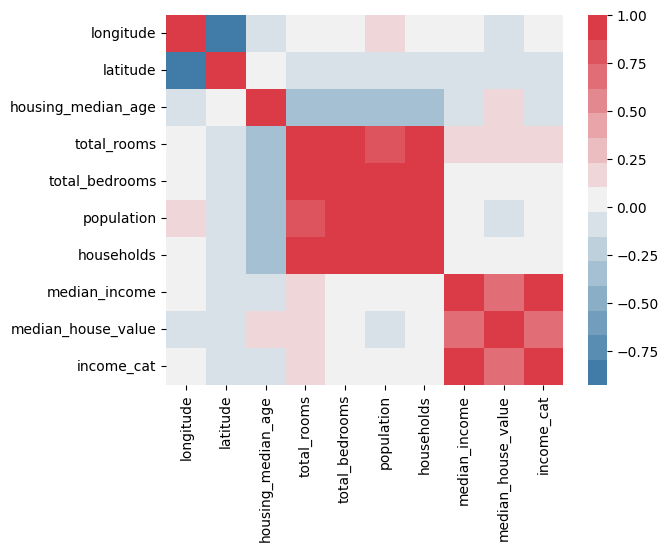

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

## Visualize the correlation with heatmap()
sns.heatmap()

In [ ]:
### Which attribute is most correlated with our target?
## compare corr score against "median_house_value"
corr_matrix['median_house_value'].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.687151
income_cat,0.642256
total_rooms,0.135140
housing_median_age,0.114146
households,0.064590
total_bedrooms,0.047781
population,-0.026882
longitude,-0.047466
latitude,-0.142673


**Note:** The correlation coefficient only measures linear correlations ("if x goes up, then y generally goes up/down"). It may completely missout on non-linear relationships) (e.g. "if x is close to zero then y generally goes up")

Another way of looking at correlation between attributes is to create a Seaborn pairplot.

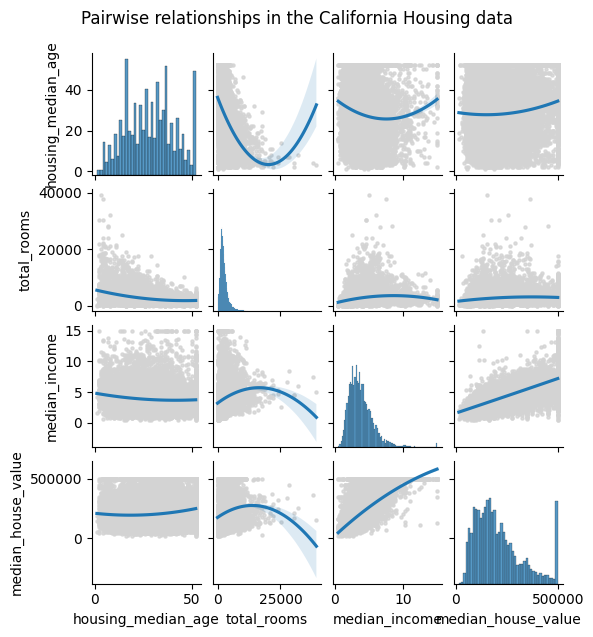

In [ ]:
import seaborn as sns
g=sns.pairplot(
    data=housing.drop(['ocean_proximity','longitude','latitude','households','population','total_bedrooms'], axis=1),
    kind="reg", # regression
    plot_kws={"scatter_kws":{"color":"lightgrey", "s":5}, "order":2},
    height=1.5 # make the individual plots small
);
g.fig.suptitle(
    "Pairwise relationships in the California Housing data", y=1.05
);

The most promising attribute to predict the median house value is the median income, so let's zoom in on their correlation scatterplot:

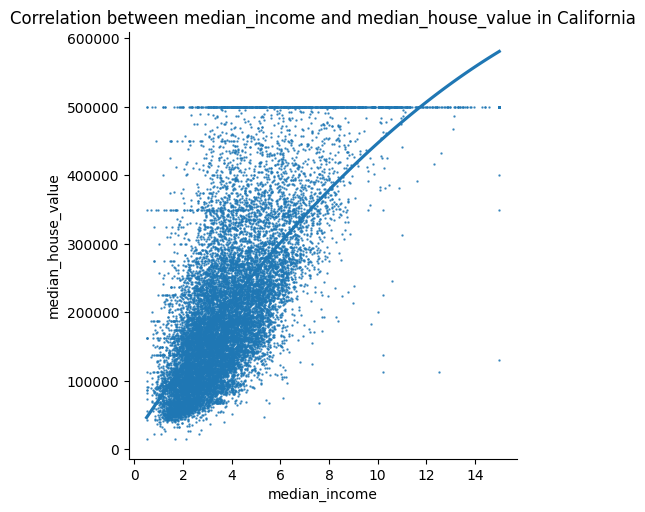

In [ ]:
# Polymonial regression plot
sns.lmplot(
    data=housing,
    x="median_income",
    y="median_house_value",
    ci=None,
    order=2,
    markers='.',
    scatter_kws={'s':2}
)
plt.title(
"Correlation between median_income and median_house_value in California"
);

Here are a few observations:
1. The correlation is very strong; you can clearly see an upward trend and the points are not too dispersed.
2. The price cap that we noticed earlier is clearly visible as a horizontal line at \$500,000.
3. There are a few more obvious straight lines at \$450,000, \$350,000, and around \$280,000. We may want to remove the corresponding districts to prevent our algorithms from learning to reproduce these data quirks.

## 4. Cross validation
Evaluate a model's performance by splitting the data into multiple subsets using the `sklearn.model_selection.cross_val_score` function. `cv` determines the cross-validation splitting strategy.

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression # Changed from LogisticRegression
from sklearn.impute import SimpleImputer # Added for handling missing values
import pandas as pd
import numpy as np

### Select your independent (X) and dependent (y) attributes
# Therefore, X_train and y_train should be directly derived from it.

# Handle missing values (na) using SimpleImputer
imputer = SimpleImputer(strategy="median")

# Fit the imputer on the numerical attributes and transform X_train
numerical_attributes = X_train.select_dtypes(include=[np.number]).columns
imputer.fit(X_train[numerical_attributes])
X_train_imputed = pd.DataFrame(imputer.transform(X_train[numerical_attributes]), columns=numerical_attributes, index=X_train.index)

### Use a linear regression model and initialize the model
lr_model = LinearRegression()

lr_model.fit()

### Perform 5-fold cross-validation
# Use 'neg_mean_squared_error' for regression and then calculate RMSE
scores = cross_val_score(<data>, <X>, <y>, <cv>)

print("Cross-validation scores:", scores)
print("Average score:", scores.mean())

